<a href="https://colab.research.google.com/github/GScaramussa/Redes/blob/main/redesCSMA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def simular_csma_npersistente(
    tempo=0.01,
    n_est=10,
    taxa_bits=1e5,
    tam_quadro=100,
    espera_max_factor=10,
    rodadas=3,
    a=0.05,
    pontos=15,
    seed=42
):
    rng = np.random.default_rng(seed)

    t_quadro = tam_quadro / taxa_bits
    dt_sim = t_quadro / tam_quadro
    t_sim = int(np.ceil(tempo / dt_sim))
    duracao_tx = int(np.ceil(tam_quadro / taxa_bits / dt_sim))

    taxa_max_quadro = int(np.ceil(taxa_bits / tam_quadro / n_est))
    taxas_quadro = taxa_max_quadro * np.arange(1 / pontos, 1 + 1 / pontos, 1 / pontos)

    quadros_entregues = np.zeros(pontos)
    quadros_colididos = np.zeros(pontos)
    quadros_bloqueados = np.zeros(pontos)

    for idx, taxa_quadro in enumerate(taxas_quadro):
        tm_q = taxa_quadro * dt_sim
        espera_max = int(np.ceil(espera_max_factor * duracao_tx))
        atraso = int(np.ceil(a * tam_quadro))

        for _ in range(rodadas):
            tx_ativo = np.zeros(n_est, dtype=int)
            tx_fila = np.zeros(n_est, dtype=int)
            tx_cnt = np.zeros(n_est, dtype=int)
            colin = np.zeros(n_est, dtype=int)
            tx_espera = np.zeros(n_est, dtype=int)
            transmis = np.zeros((n_est, t_sim), dtype=int)

            chegada_quadros = 0
            colisoes = 0
            entregues = 0
            bloqueios = 0

            for k in range(t_sim):
                if k > atraso:
                    tx_ativo_atr = transmis[:, k - atraso]
                else:
                    tx_ativo_atr = np.zeros(n_est, dtype=int)

                for j in range(n_est):
                    if tx_ativo[j] == 1:
                        transmis[j, k] = 1

                    if tx_cnt[j] > 0:
                        tx_cnt[j] -= 1
                        if tx_cnt[j] == 0:
                            tx_ativo[j] = 0
                            if colin[j] == 1:
                                tx_espera[j] = int(np.ceil(espera_max * rng.random()))
                                tx_fila[j] += 1
                                colin[j] = 0
                                colisoes += 1
                            else:
                                entregues += 1
                    else:
                        if tx_fila[j] > 0:
                            if (tx_espera[j] == 0) and (np.count_nonzero(tx_ativo_atr) == 0):
                                tx_ativo[j] = 1
                                tx_cnt[j] = duracao_tx
                                tx_fila[j] -= 1
                            elif tx_espera[j] > 0:
                                tx_espera[j] -= 1
                            elif np.count_nonzero(tx_ativo_atr) > 0:
                                tx_espera[j] = int(np.ceil(espera_max * rng.random()))
                                bloqueios += 1

                    if rng.random() < tm_q:
                        chegada_quadros += 1
                        if (tx_ativo[j] == 0) and (tx_espera[j] == 0) and (np.count_nonzero(tx_ativo_atr) == 0):
                            tx_ativo[j] = 1
                            tx_cnt[j] = duracao_tx
                        else:
                            tx_fila[j] += 1
                            if (tx_espera[j] == 0) and (np.count_nonzero(tx_ativo_atr) > 0):
                                tx_espera[j] = int(np.ceil(espera_max * rng.random()))
                                bloqueios += 1

                if np.count_nonzero(tx_ativo) > 1:
                    colin = np.logical_or(colin, tx_ativo).astype(int)

            quadros_entregues[idx] += entregues / rodadas
            quadros_colididos[idx] += colisoes / rodadas
            quadros_bloqueados[idx] += bloqueios / rodadas

    G = np.arange(0, 1.51, 0.01)
    S = (G * np.exp(-a * G)) / (G * (1 + 2 * a) + np.exp(-a * G))

    x_sim = (quadros_colididos + quadros_entregues + quadros_bloqueados) * tam_quadro / tempo
    y_sim = quadros_entregues * tam_quadro / tempo
    x_teo = G * taxa_bits
    y_teo = S * taxa_bits

    return {
        "x_sim": x_sim,
        "y_sim": y_sim,
        "x_teo": x_teo,
        "y_teo": y_teo
    }


def plot_variacao(parametro, valores, base_params, titulo, legenda_fmt):
    plt.figure(figsize=(9, 6))

    for i, valor in enumerate(valores):
        params = base_params.copy()
        params[parametro] = valor
        params["seed"] = base_params.get("seed", 42) + i

        r = simular_csma_npersistente(**params)

        linha, = plt.plot(
            r["x_sim"], r["y_sim"], "o-",
            linewidth=1.6, markersize=4,
            label=f"Simulação — {legenda_fmt(valor)}"
        )

        plt.plot(
            r["x_teo"], r["y_teo"], "--",
            linewidth=1.4, alpha=0.9,
            color=linha.get_color(),
            label=f"Teoria — {legenda_fmt(valor)}"
        )

    plt.grid(True)
    plt.xlabel("Taxa de geração / carga oferecida (bps)")
    plt.ylabel("Taxa de entrega / capacidade (bps)")
    plt.title(titulo)
    plt.legend()
    plt.show()


base = {
    "tempo": 0.01,
    "n_est": 10,
    "taxa_bits": 1e5,
    "tam_quadro": 100,
    "espera_max_factor": 10,
    "rodadas": 3,
    "a": 0.05,
    "pontos": 15,
    "seed": 42
}

Tempo de execucao para a = 0.03: 1.0231 s
Tempo de execucao para a = 0.05: 1.5001 s
Tempo de execucao para a = 0.1: 1.5460 s


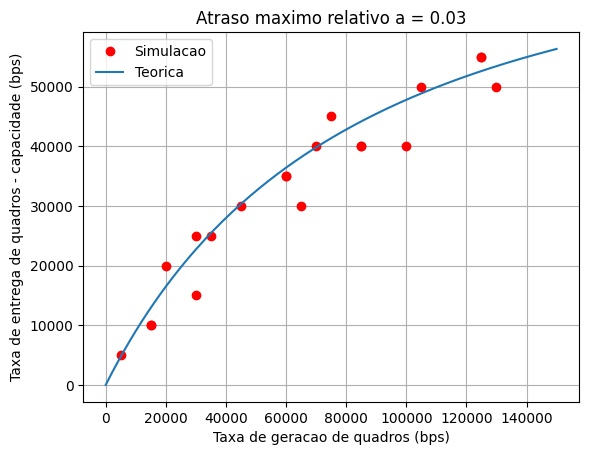

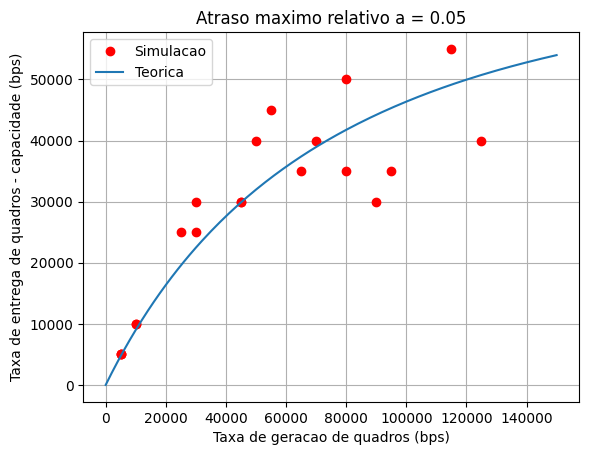

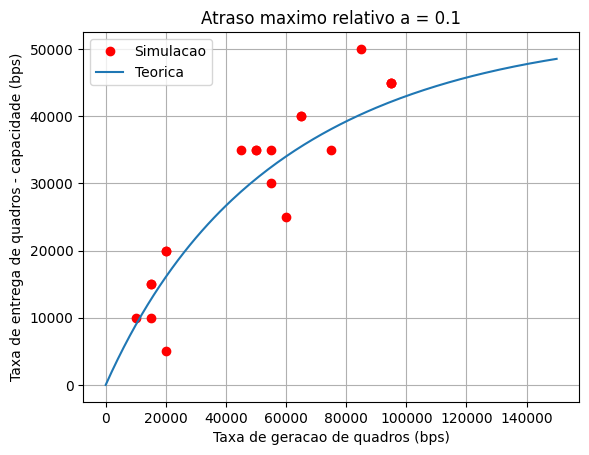

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time

# PARAMETROS DE SIMULACAO
# simulacao do protocolo CSMA nao-persistente

# tempo total da simulacao em segundos
tempo = 0.01

# numero total de estacoes
n_est = 10

# taxa de transmissao do meio em bits por segundo
taxa_bits = 1e5

# tamanho do quadro em bits
tam_quadro = 100

# tempo de transmissao do quadro em segundos
t_quadro = tam_quadro / taxa_bits

# intervalo de tempo da simulacao
dt_sim = t_quadro / tam_quadro

# tempo total da simulacao em instantes
t_sim = int(np.ceil(tempo / dt_sim))

# taxa media maxima de chegada de quadros por segundo para cada estacao
taxa_max_quadro = int(np.ceil(taxa_bits / tam_quadro / n_est))

# variacao da taxa de geracao de quadros
pontos = 20
taxas_quadro = taxa_max_quadro * np.arange(1/pontos, 1 + 1/pontos, 1/pontos)

fig = 1

for a in [0.03, 0.05, 0.1]:

    # resultados da simulacao
    quadros_transmitidos = np.zeros(taxa_max_quadro)
    quadros_entregues = np.zeros(taxa_max_quadro)
    quadros_gerados = np.zeros(taxa_max_quadro)
    quadros_colididos = np.zeros(taxa_max_quadro)
    quadros_bloqueados = np.zeros(taxa_max_quadro)

    inicio = time.time()

    for taxa in range(pontos):
        taxa_quadro = taxas_quadro[taxa]

        # taxa media de chegada de quadros por instante de simulacao
        tm_q = taxa_quadro * dt_sim

        # janela de tempo de espera aleatoria em numero de instantes de simulacao
        espera_max = 10 * tam_quadro

        # numero de repeticoes da simulacao - para tirar a media
        rodadas = 2

        for r in range(rodadas):

            # VARIAVEIS DOS EVENTOS

            # transmissores ativos
            tx_ativo = np.zeros(n_est, dtype=int)

            # fila de quadros do transmissor
            tx_fila = np.zeros(n_est, dtype=int)

            # contador de progresso do transmissor
            tx_cnt = np.zeros(n_est, dtype=int)

            # armazenador de colisoes
            colis = np.zeros(t_sim, dtype=int)

            # indices das estacoes com colisao
            colin = np.zeros(n_est, dtype=int)

            # espera aleatoria em caso de colisao
            tx_espera = np.zeros(n_est, dtype=int)

            # armazenador das transmissoes
            transmis = np.zeros((n_est, t_sim), dtype=int)

            # armazenador da chegada dos quadros
            chegada_quadros = 0

            # armazenador de quadros colididos
            colisoes = 0

            # armazenador de quadros entregues
            entregues = 0

            # armazenador de bloqueios
            bloqueios = 0

            # guarda o estado do meio (com atraso)
            tx_ativo_atr = np.zeros(n_est, dtype=int)

            # atraso de propagacao
            atraso = int(np.ceil(a * tam_quadro / taxa_bits / dt_sim))

            for k in range(t_sim):

                # guarda o estado do meio (com atraso)
                if k > atraso:
                    tx_ativo_atr = transmis[:, k - atraso]
                else:
                    tx_ativo_atr = np.zeros(n_est, dtype=int)

                for j in range(n_est):

                    # verificar se o transmissor esta ativo
                    if tx_ativo[j] == 1:
                        transmis[j, k] = 1

                    # verificar se o quadro foi enviado
                    if tx_cnt[j] > 0:
                        tx_cnt[j] -= 1

                        if tx_cnt[j] == 0:
                            tx_ativo[j] = 0

                            # verificar se a transmissao sofreu colisao
                            if colin[j] == 1:
                                tx_espera[j] = int(np.ceil(espera_max * np.random.rand()))
                                tx_fila[j] += 1
                                colin[j] = 0
                                colisoes += 1
                            else:
                                entregues += 1

                    else:
                        # verificar se tem quadros em espera e se o meio esta livre
                        if tx_fila[j] > 0:
                            if (tx_espera[j] == 0) and (np.count_nonzero(tx_ativo_atr) == 0):
                                tx_ativo[j] = 1
                                tx_cnt[j] = int(np.ceil(tam_quadro / taxa_bits / dt_sim))
                                tx_fila[j] -= 1

                            elif tx_espera[j] > 0:
                                # decrementar o contador do tempo de espera
                                tx_espera[j] -= 1

                            elif np.count_nonzero(tx_ativo_atr) > 0:
                                # meio esta ocupado - modo nao-persistente
                                tx_espera[j] = int(np.ceil(espera_max * np.random.rand()))
                                bloqueios += 1

                    # verificar se chegou um novo quadro
                    p_novo = np.random.rand()

                    if p_novo < tm_q:
                        chegada_quadros += 1

                        # verificar se o transmissor esta pronto
                        if (tx_ativo[j] == 0) and (tx_espera[j] == 0) and (np.count_nonzero(tx_ativo_atr) == 0):
                            tx_ativo[j] = 1
                            tx_cnt[j] = int(np.ceil(tam_quadro / taxa_bits / dt_sim))
                        else:
                            tx_fila[j] += 1

                            if (tx_espera[j] == 0) and (np.count_nonzero(tx_ativo_atr) > 0):
                                # meio ocupado
                                tx_espera[j] = int(np.ceil(espera_max * np.random.rand()))
                                bloqueios += 1

                # verifica se houve colisao
                if np.count_nonzero(tx_ativo) > 1:
                    colis[k] = 1
                    colin = np.logical_or(colin, tx_ativo).astype(int)

            quadros_transmitidos[taxa] += ((chegada_quadros - np.sum(tx_fila))) / rodadas
            quadros_entregues[taxa] += entregues / rodadas
            quadros_gerados[taxa] += chegada_quadros / rodadas
            quadros_colididos[taxa] += colisoes / rodadas
            quadros_bloqueados[taxa] += bloqueios / rodadas

    fim = time.time()
    print(f"Tempo de execucao para a = {a}: {fim - inicio:.4f} s")

    # CSMA nao-persistente
    G = np.arange(0, 1.51, 0.01)
    S = (G * np.exp(-a * G)) / (G * (1 + 2 * a) + np.exp(-a * G))  # nao slotted

    plt.figure(fig)
    fig += 1

    plt.plot(
        (quadros_colididos[:pontos] + quadros_entregues[:pontos] + quadros_bloqueados[:pontos]) * tam_quadro / tempo,
        quadros_entregues[:pontos] * tam_quadro / tempo,
        'ro',
        label='Simulacao'
    )

    plt.plot(
        G * taxa_bits,
        S * taxa_bits,
        '-',
        label='Teorica'
    )

    plt.grid(True)
    plt.title(f'Atraso maximo relativo a = {a}')
    plt.xlabel('Taxa de geracao de quadros (bps)')
    plt.ylabel('Taxa de entrega de quadros - capacidade (bps)')
    plt.legend()

plt.show()

2

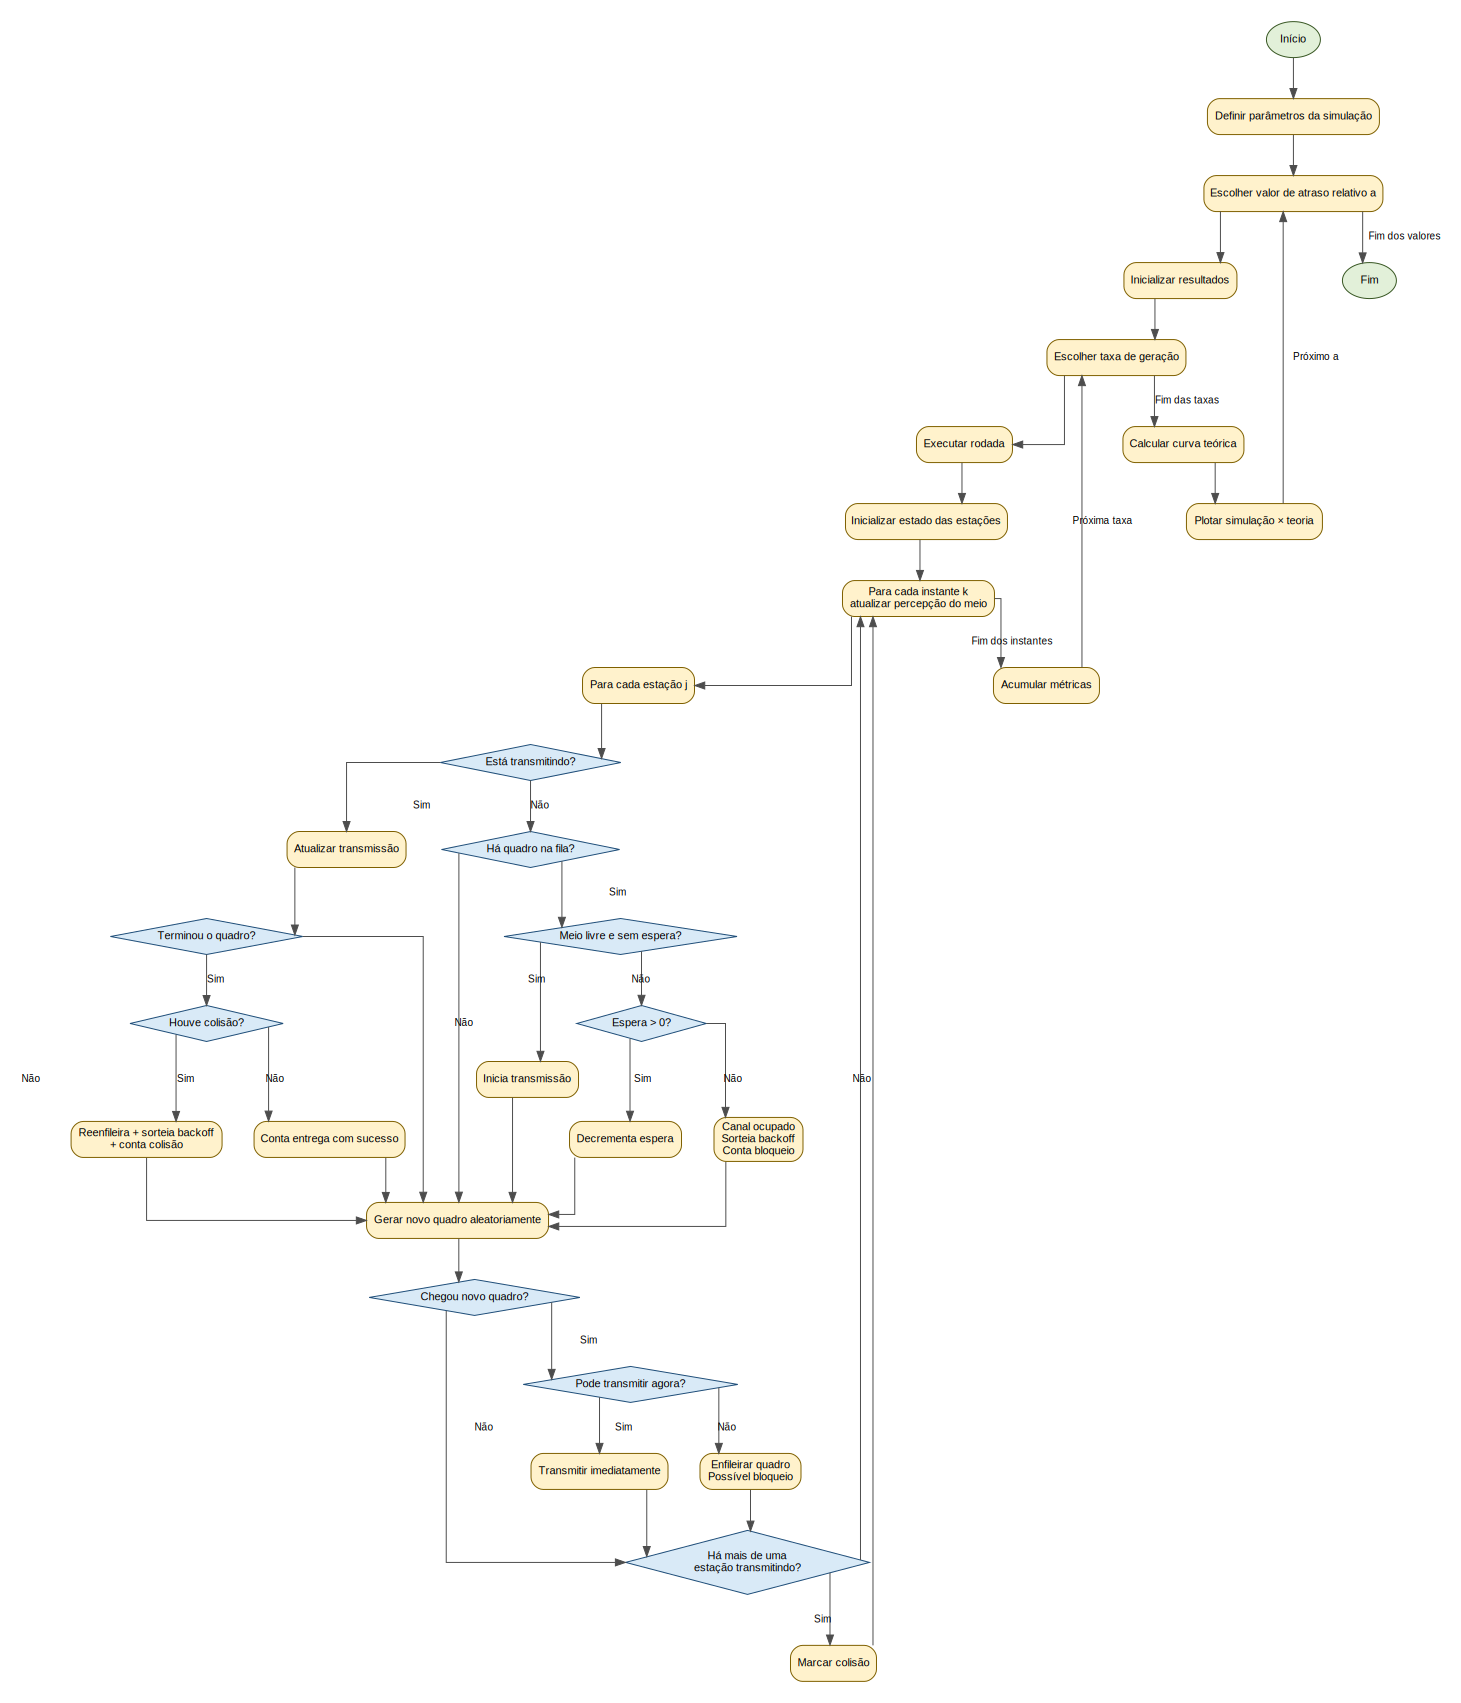

In [ ]:
!apt-get -qq install graphviz
!pip -q install graphviz

from graphviz import Digraph
from IPython.display import display

dot = Digraph('CSMA_Fluxograma', format='png')
dot.attr(rankdir='TB', splines='ortho', pad='0.3', nodesep='0.45', ranksep='0.55')
dot.attr('edge', fontname='Arial', fontsize='10', color='gray30')

def proc(id_, txt):
    dot.node(id_, txt, shape='rectangle', style='rounded,filled',
             fillcolor='#FFF2CC', color='#7F6000', fontname='Arial', fontsize='11')

def decis(id_, txt):
    dot.node(id_, txt, shape='diamond', style='filled',
             fillcolor='#D9EAF7', color='#1F4E79', fontname='Arial', fontsize='11')

def term(id_, txt):
    dot.node(id_, txt, shape='oval', style='filled',
             fillcolor='#E2F0D9', color='#385723', fontname='Arial', fontsize='11')

term('A', 'Início')
proc('B', 'Definir parâmetros da simulação')
proc('C', 'Escolher valor de atraso relativo a')
proc('D', 'Inicializar resultados')
proc('E', 'Escolher taxa de geração')
proc('F', 'Executar rodada')
proc('G', 'Inicializar estado das estações')
proc('H', 'Para cada instante k\\natualizar percepção do meio')
proc('I', 'Para cada estação j')
decis('J', 'Está transmitindo?')
proc('K', 'Atualizar transmissão')
decis('L', 'Terminou o quadro?')
decis('M', 'Houve colisão?')
proc('N', 'Reenfileira + sorteia backoff\\n+ conta colisão')
proc('O', 'Conta entrega com sucesso')
decis('P', 'Há quadro na fila?')
decis('Q', 'Meio livre e sem espera?')
proc('R', 'Inicia transmissão')
decis('S', 'Espera > 0?')
proc('T', 'Decrementa espera')
proc('U', 'Canal ocupado\\nSorteia backoff\\nConta bloqueio')
proc('V', 'Gerar novo quadro aleatoriamente')
decis('W', 'Chegou novo quadro?')
decis('X', 'Pode transmitir agora?')
proc('Y', 'Transmitir imediatamente')
proc('Z', 'Enfileirar quadro\\nPossível bloqueio')
decis('AA', 'Há mais de uma\\nestação transmitindo?')
proc('AB', 'Marcar colisão')
proc('AC', 'Acumular métricas')
proc('AD', 'Calcular curva teórica')
proc('AE', 'Plotar simulação × teoria')
term('AF', 'Fim')

for u, v, lbl in [
    ('A','B',''), ('B','C',''), ('C','D',''), ('D','E',''), ('E','F',''),
    ('F','G',''), ('G','H',''), ('H','I',''), ('I','J',''),
    ('J','K','Sim'), ('J','P','Não'),
    ('K','L',''), ('L','M','Sim'), ('L','V','Não'),
    ('M','N','Sim'), ('M','O','Não'),
    ('N','V',''), ('O','V',''),
    ('P','Q','Sim'), ('P','V','Não'),
    ('Q','R','Sim'), ('Q','S','Não'),
    ('S','T','Sim'), ('S','U','Não'),
    ('R','V',''), ('T','V',''), ('U','V',''),
    ('V','W',''),
    ('W','X','Sim'), ('W','AA','Não'),
    ('X','Y','Sim'), ('X','Z','Não'),
    ('Y','AA',''), ('Z','AA',''),
    ('AA','AB','Sim'), ('AA','H','Não'),
    ('AB','H',''),
    ('H','AC','Fim dos instantes'),
    ('AC','E','Próxima taxa'),
    ('E','AD','Fim das taxas'),
    ('AD','AE',''),
    ('AE','C','Próximo a'),
    ('C','AF','Fim dos valores')
]:
    if lbl:
        dot.edge(u, v, label=lbl)
    else:
        dot.edge(u, v)

display(dot)

A simulação modela um sistema com várias estações compartilhando um meio comum de transmissão, sob a lógica do protocolo CSMA não-persistente. Inicialmente, são definidos os parâmetros do sistema, como número de estações, taxa de transmissão, tamanho do quadro, duração da simulação e atraso de propagação relativo. Em seguida, para cada valor de atraso e para cada taxa de geração de quadros, o programa executa várias rodadas de simulação. Em cada rodada, cada estação pode gerar quadros aleatoriamente ao longo do tempo. Quando uma estação possui quadro para transmitir, ela verifica o estado do meio; se o canal estiver livre, inicia a transmissão, e se estiver ocupado, espera um intervalo aleatório antes de tentar novamente, conforme a lógica não-persistente. O estado percebido do meio considera um atraso de propagação, o que permite que duas ou mais estações interpretem simultaneamente que o canal está livre e iniciem transmissão ao mesmo tempo, produzindo colisões. Quando há colisão, o quadro não é considerado entregue, retorna à fila da estação e aguarda nova tentativa após um tempo de espera aleatório. Ao final de cada experimento, o programa contabiliza quadros gerados, entregues, colididos e bloqueados, e compara o resultado médio obtido com a expressão teórica do CSMA não-persistente.

Na simulação, o funcionamento da rede é representado de forma simplificada para permitir a análise do protocolo CSMA não-persistente, mas esse modelo não reproduz integralmente todas as condições de uma situação real. Em primeiro lugar, o tempo é tratado de forma discretizada, isto é, dividido em pequenos intervalos fixos, enquanto em uma rede real os eventos ocorrem de maneira contínua. Além disso, a geração de quadros é feita por meio de um processo aleatório simples, com probabilidade constante a cada instante, o que facilita os cálculos, mas não representa perfeitamente o tráfego real, que costuma variar ao longo do tempo e pode ocorrer em rajadas. Outro ponto é que todas as estações são consideradas iguais no modelo, com o mesmo comportamento, a mesma taxa de transmissão e as mesmas regras de espera, ao passo que, na prática, diferentes dispositivos podem apresentar capacidades, cargas e tempos de resposta distintos.

Também há simplificações em relação ao meio de transmissão. Na simulação, o canal é modelado basicamente a partir do atraso de propagação e da possibilidade de colisão, sem incluir efeitos como ruído, interferência, erros físicos, falhas de hardware ou variações de sinal. O mecanismo de espera aleatória após colisões ou bloqueios também é tratado de forma simplificada, com uma janela fixa de backoff, enquanto sistemas reais podem empregar estratégias mais complexas de retransmissão. Além disso, o modelo considera filas sem limitação explícita de capacidade, o que difere da realidade, onde os buffers são finitos e podem causar descarte de quadros em situações de congestionamento. Por fim, a simulação observa a colisão como consequência da sobreposição de transmissões, mas não necessariamente reproduz todos os detalhes de detecção e interrupção imediata existentes em implementações reais. Assim, a simulação é adequada para estudar o comportamento geral do protocolo e comparar resultados com a teoria, mas deve ser entendida como uma aproximação controlada e não como uma reprodução completa de uma rede real.

## A) Influência do tempo de simulação

Nesta etapa, varia-se o tempo total da simulação, mantendo os demais parâmetros fixos. O objetivo é observar se um intervalo maior de observação aproxima os resultados simulados da curva teórica do CSMA não-persistente.

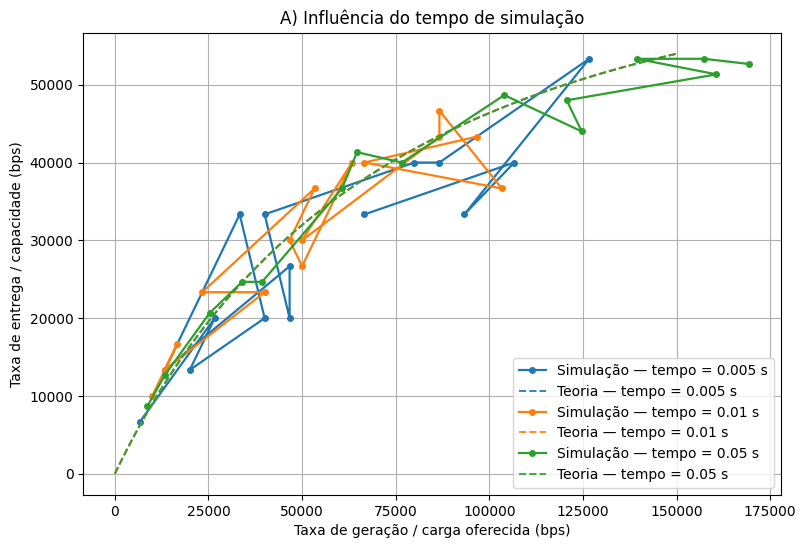

In [4]:
valores_tempo = [0.005, 0.01, 0.05]

plot_variacao(
    parametro="tempo",
    valores=valores_tempo,
    base_params=base,
    titulo="A) Influência do tempo de simulação",
    legenda_fmt=lambda v: f"tempo = {v} s"
)

Com a ampliação do tempo de simulação, os pontos simulados tendem a ficar menos irregulares e mais próximos da curva teórica. Isso ocorre porque um tempo maior produz mais eventos de transmissão, colisão e retransmissão, reduzindo a influência do acaso sobre a média final. Portanto, esse parâmetro não altera o modelo teórico em si, mas melhora a estabilidade estatística da simulação.

## B) Influência do número de estações

Nesta análise, varia-se a quantidade de estações compartilhando o meio, mantendo os demais parâmetros constantes. O objetivo é verificar como a distribuição da carga entre mais ou menos transmissores afeta a proximidade entre simulação e teoria.

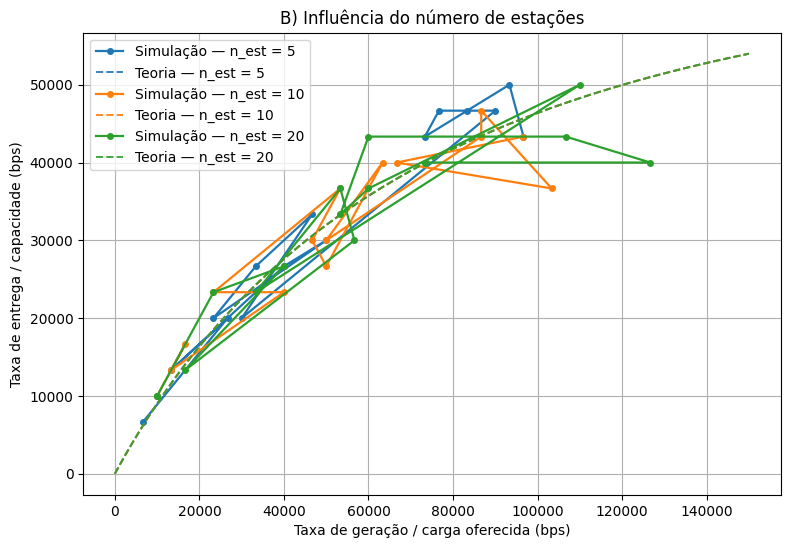

In [5]:
valores_n_est = [5, 10, 20]

plot_variacao(
    parametro="n_est",
    valores=valores_n_est,
    base_params=base,
    titulo="B) Influência do número de estações",
    legenda_fmt=lambda v: f"n_est = {v}"
)

## C) Influência da taxa de transmissão

Aqui, altera-se a taxa de transmissão do meio em bits por segundo. O objetivo é observar como essa mudança afeta a escala absoluta dos resultados em bps, tanto na simulação quanto na curva teórica.

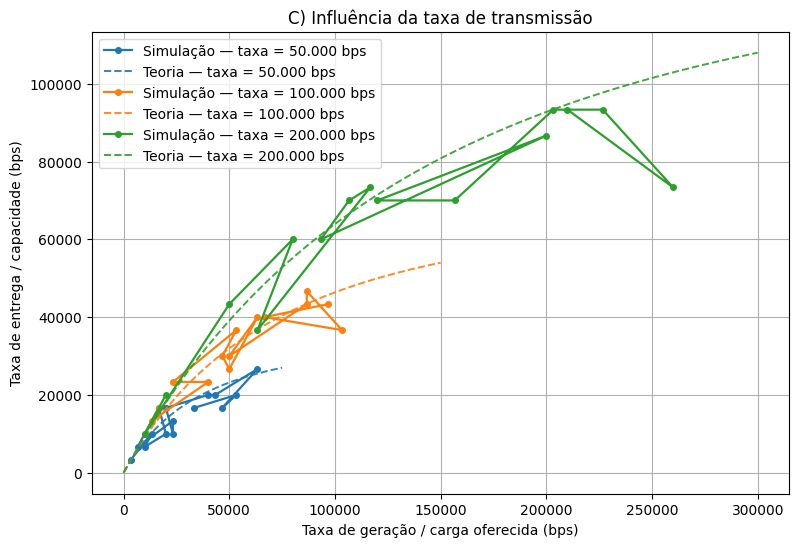

In [6]:
valores_taxa_bits = [5e4, 1e5, 2e5]

plot_variacao(
    parametro="taxa_bits",
    valores=valores_taxa_bits,
    base_params=base,
    titulo="C) Influência da taxa de transmissão",
    legenda_fmt=lambda v: f"taxa = {int(v):,} bps".replace(",", ".")
)

Quando a taxa de transmissão aumenta, a capacidade do canal em bits por segundo também aumenta, deslocando as curvas para valores mais altos no gráfico. Em termos absolutos, a rede entrega mais bits por unidade de tempo. Entretanto, a forma geral da curva tende a permanecer semelhante, pois o efeito principal desse parâmetro está na escala do sistema, e não necessariamente na lógica de acesso ao meio.

## D) Influência do tamanho do quadro

Nesta etapa, altera-se o tamanho do quadro transmitido, mantendo os demais parâmetros fixos. O objetivo é verificar o impacto do tempo de ocupação do meio por transmissão sobre a capacidade observada.

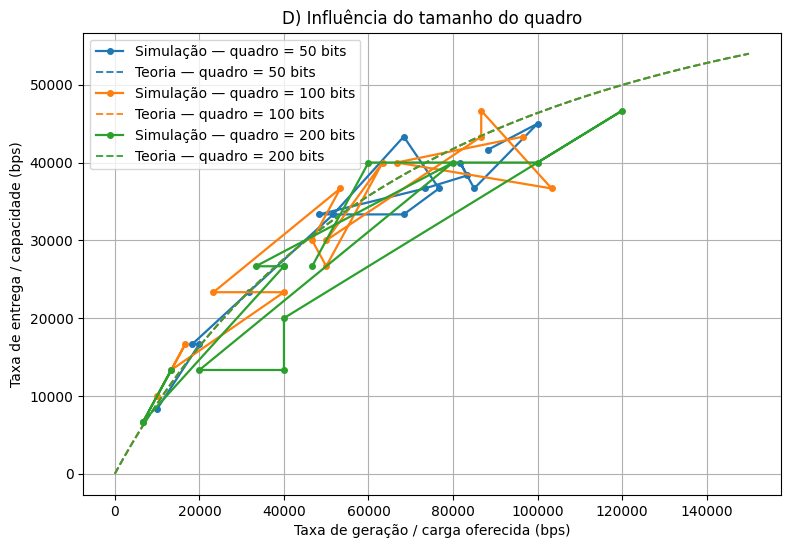

In [7]:
valores_tam_quadro = [50, 100, 200]

plot_variacao(
    parametro="tam_quadro",
    valores=valores_tam_quadro,
    base_params=base,
    titulo="D) Influência do tamanho do quadro",
    legenda_fmt=lambda v: f"quadro = {v} bits"
)

O tamanho do quadro altera o tempo necessário para concluir cada transmissão. Quadros maiores ocupam o meio por mais tempo a cada tentativa, enquanto quadros menores produzem transmissões mais curtas e frequentes. Na prática, esse parâmetro modifica a dinâmica temporal da simulação e pode alterar o quanto as colisões afetam a eficiência observada, especialmente quando comparado ao atraso de propagação.

## E) Influência da janela máxima de espera aleatória

Aqui, varia-se o fator que define o limite máximo do backoff aleatório após colisões ou canal ocupado. O objetivo é avaliar o efeito dessa janela sobre colisões repetidas e períodos de ociosidade.

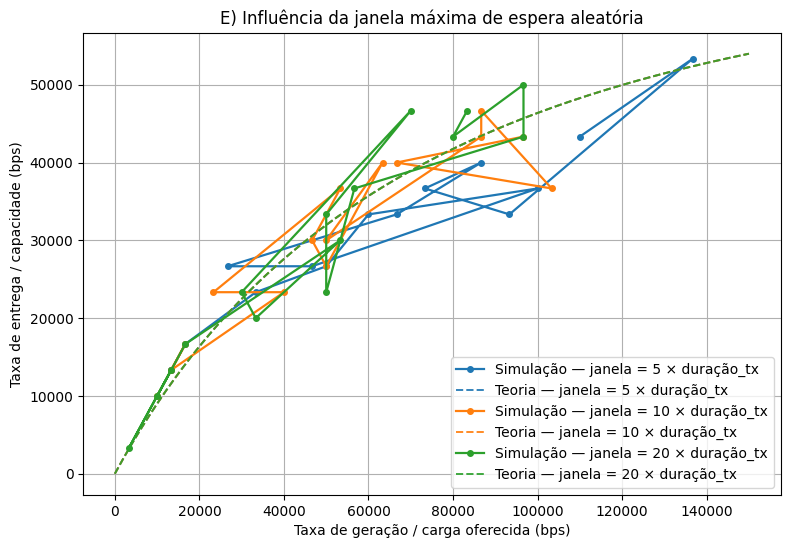

In [8]:
valores_espera = [5, 10, 20]

plot_variacao(
    parametro="espera_max_factor",
    valores=valores_espera,
    base_params=base,
    titulo="E) Influência da janela máxima de espera aleatória",
    legenda_fmt=lambda v: f"janela = {v} × duração_tx"
)

Quando a janela de espera é muito pequena, várias estações voltam a tentar transmitir quase ao mesmo tempo, aumentando a chance de novas colisões e piorando o desempenho. Quando essa janela é muito grande, o meio tende a ficar ocioso por mais tempo do que o necessário. Assim, esse parâmetro não aparece explicitamente no modelo teórico, mas influencia fortemente a distância entre a simulação e a curva ideal.

## F) Influência do número de rodadas

Nesta análise, varia-se a quantidade de repetições independentes da simulação para cada ponto do gráfico. O objetivo é verificar como o cálculo da média afeta a regularidade da curva simulada.

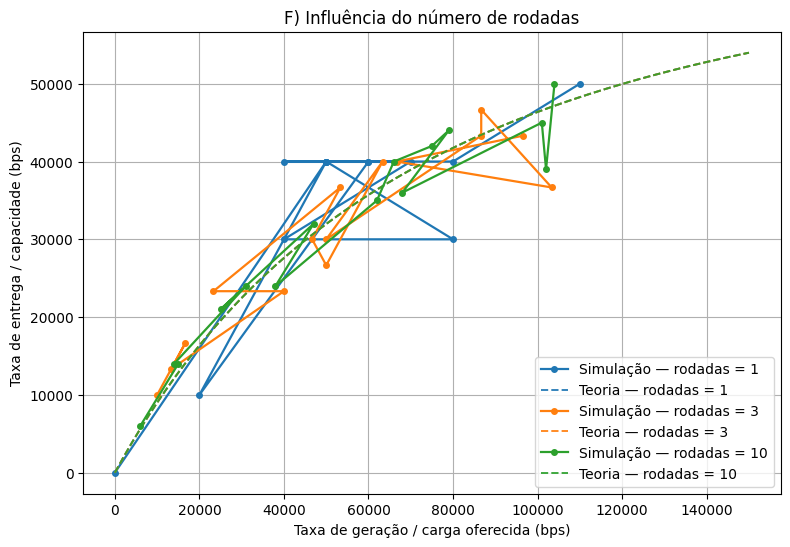

In [9]:
valores_rodadas = [1, 3, 10]

plot_variacao(
    parametro="rodadas",
    valores=valores_rodadas,
    base_params=base,
    titulo="F) Influência do número de rodadas",
    legenda_fmt=lambda v: f"rodadas = {v}"
)

O aumento do número de rodadas tende a suavizar a curva simulada, pois a média passa a ser calculada sobre um conjunto maior de execuções. Com poucas rodadas, o gráfico fica mais sujeito a oscilações aleatórias. Portanto, esse parâmetro não muda o comportamento teórico do protocolo, mas melhora a confiabilidade estatística do resultado obtido.

## G) Influência da relação entre atraso de propagação e tempo de transmissão do quadro

Nesta etapa, varia-se o parâmetro `a`, que representa a razão entre o atraso de propagação e o tempo de transmissão de um quadro. Esse é o parâmetro mais diretamente associado ao modelo teórico do CSMA não-persistente.

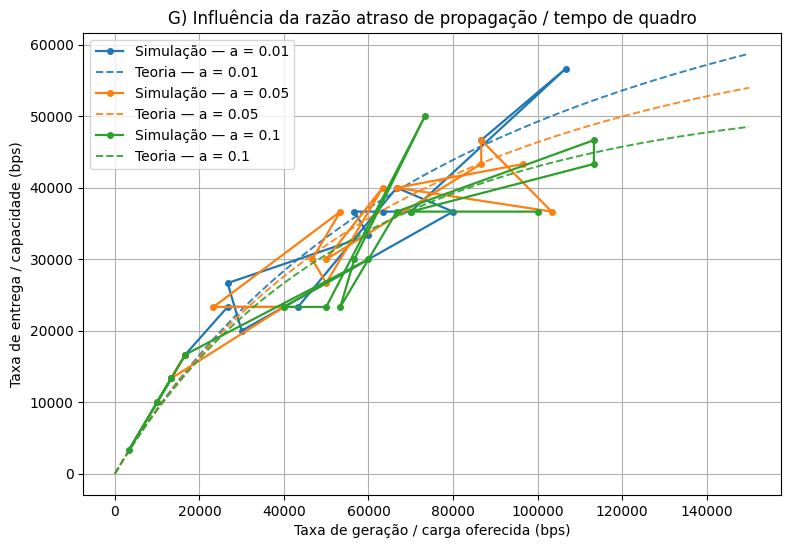

In [10]:
valores_a = [0.01, 0.05, 0.10]

plot_variacao(
    parametro="a",
    valores=valores_a,
    base_params=base,
    titulo="G) Influência da razão atraso de propagação / tempo de quadro",
    legenda_fmt=lambda v: f"a = {v}"
)

À medida que o valor de `a` aumenta, o atraso de propagação passa a representar uma parcela mais relevante do tempo total de transmissão. Isso aumenta a chance de duas ou mais estações perceberem o meio como livre quase ao mesmo tempo, elevando a probabilidade de colisão. Como consequência, a capacidade máxima do sistema diminui, e tanto a curva teórica quanto a simulada se deslocam para baixo.